# 📐 Linear Algebra Basics for AI & Machine Learning

Linear Algebra is the fundamental mathematical language of AI. In machine learning:
- **Data points** are represented as **vectors**.
- **Datasets and weights** are structured as **matrices**.
- **Model predictions and feature transformations** are executed via **linear transformations and matrix multiplications**.

In this notebook, we explore core linear algebra concepts with **interactive code and visual plots**.


---
## 1. Vector Operations & Geometric Visualization

A vector $\mathbf{v} \in \mathbb{R}^n$ represents both a point in space and a direction with magnitude.
- **Addition**: $\mathbf{u} + \mathbf{v} = [u_1+v_1, u_2+v_2]$
- **Scalar Scaling**: $c \cdot \mathbf{v} = [c v_1, c v_2]$
- **Euclidean Norm ($L_2$)**: $\|\mathbf{v}\|_2 = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2}$


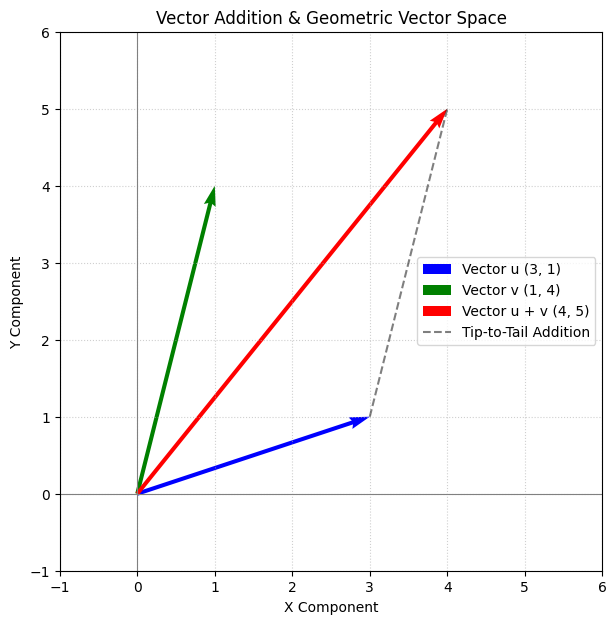

L2 Norm of u: 3.1623
L2 Norm of v: 4.1231
L2 Norm of u+v: 6.4031


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define 2D vectors
u = np.array([3, 1])
v = np.array([1, 4])
w = u + v

# Plotting vectors geometrically
plt.figure(figsize=(7, 7))
plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector u (3, 1)')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='green', label='Vector v (1, 4)')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='red', label='Vector u + v (4, 5)')

# Add vector tip-to-tail dashed line for visual proof
plt.plot([u[0], w[0]], [u[1], w[1]], 'k--', alpha=0.5, label='Tip-to-Tail Addition')

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Vector Addition & Geometric Vector Space')
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.legend()
plt.show()

print(f'L2 Norm of u: {np.linalg.norm(u):.4f}')
print(f'L2 Norm of v: {np.linalg.norm(v):.4f}')
print(f'L2 Norm of u+v: {np.linalg.norm(w):.4f}')


---
## 2. Cosine Similarity & Vector Embeddings

The dot product $\mathbf{u} \cdot \mathbf{v} = \sum u_i v_i = \|\mathbf{u}\| \|\mathbf{v}\| \cos(\theta)$ measures direction alignment.
**Cosine Similarity** normalizes out the magnitude to give the cosine of the angle:
$$\cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}$$


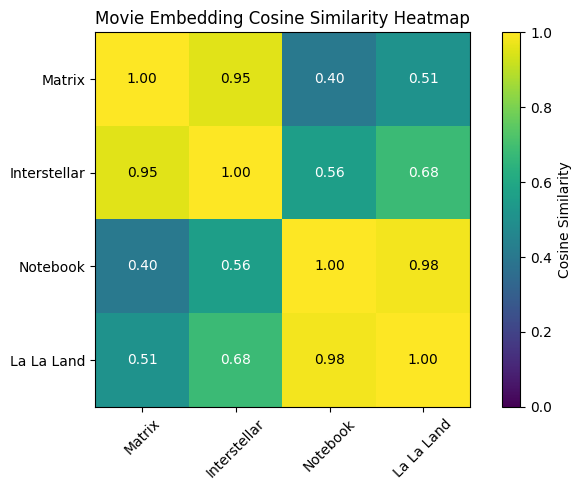

In [7]:
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Movie Embeddings [Action, SciFi, Romance]
movie_matrix = {
    'Matrix': np.array([5.0, 5.0, 1.0]),
    'Interstellar': np.array([3.0, 5.0, 2.0]),
    'Notebook': np.array([1.0, 1.0, 5.0]),
    'La La Land': np.array([1.0, 2.0, 5.0])
}

# Compute pair-wise similarity matrix
names = list(movie_matrix.keys())
n = len(names)
sim_grid = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_grid[i, j] = cosine_similarity(movie_matrix[names[i]], movie_matrix[names[j]])

# Heatmap visual plot
plt.figure(figsize=(7, 5))
plt.imshow(sim_grid, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(n), names, rotation=45)
plt.yticks(range(n), names)
for i in range(n):
    for j in range(n):
        plt.text(j, i, f'{sim_grid[i, j]:.2f}', ha='center', va='center', color='white' if sim_grid[i, j] < 0.7 else 'black')
plt.title('Movie Embedding Cosine Similarity Heatmap')
plt.tight_layout()
plt.show()


---
## 3. Matrices as Linear Transformations

Multiplying a vector $\mathbf{x}$ by a matrix $A$ transforms $\mathbf{x}$ into a new space $A\mathbf{x}$.
Let's visualize how a rotation and scaling matrix warps a 2D grid.


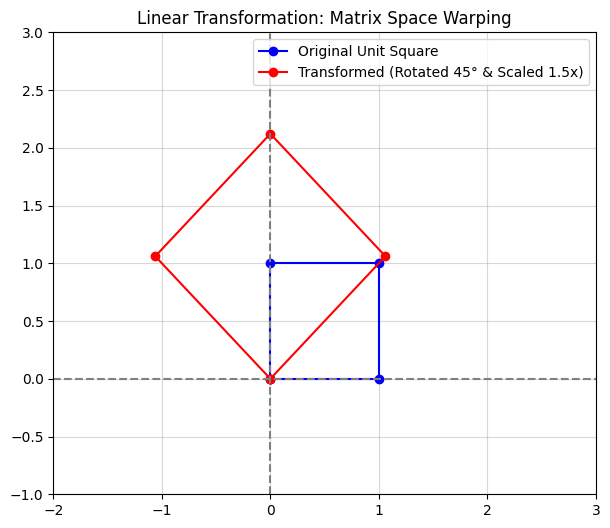

In [8]:
# Create a grid of points forming a square
theta = np.radians(45)  # 45-degree rotation
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])* 1.5  # Rotation + Scaling by 1.5

# Square vertices
square = np.array([
    [0, 0], [1, 0], [1, 1], [0, 1], [0, 0]
]).T

# Transform vertices: A @ square
transformed_square = R @ square

plt.figure(figsize=(7, 6))
plt.plot(square[0, :], square[1, :], 'b-o', label='Original Unit Square')
plt.plot(transformed_square[0, :], transformed_square[1, :], 'r-o', label='Transformed (Rotated 45° & Scaled 1.5x)')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlim(-2, 3)
plt.ylim(-1, 3)
plt.grid(True, alpha=0.5)
plt.title('Linear Transformation: Matrix Space Warping')
plt.legend()
plt.show()


---
## 4. Systems of Linear Equations & Inverse Matrices

Solving $A \mathbf{x} = \mathbf{b}$ finds the point of intersection between linear hyperplanes.
If $\det(A) \neq 0$, then $\mathbf{x} = A^{-1} \mathbf{b}$.


Determinant of A: 5.0000
Solution vector [x, y]: [3. 2.]


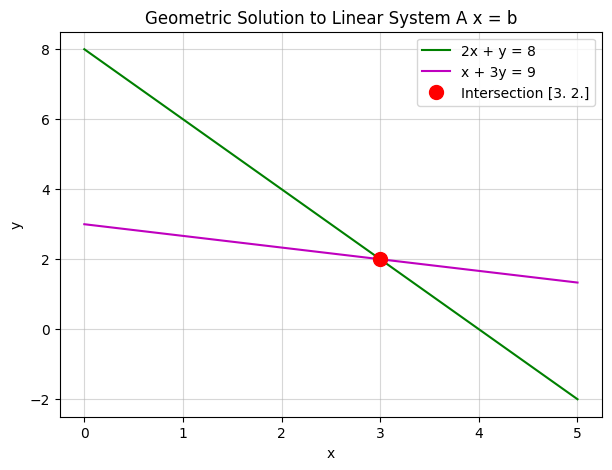

In [9]:
# System:
#  2x +  y = 8
#   x + 3y = 9
A = np.array([[2, 1], [1, 3]])
b = np.array([8, 9])

# Solve x
x_sol = np.linalg.solve(A, b)
print(f'Determinant of A: {np.linalg.det(A):.4f}')
print(f'Solution vector [x, y]: {x_sol}')

# Plot lines
x_vals = np.linspace(0, 5, 100)
y1 = 8 - 2 * x_vals
y2 = (9 - x_vals) / 3

plt.figure(figsize=(7, 5))
plt.plot(x_vals, y1, 'g-', label='2x + y = 8')
plt.plot(x_vals, y2, 'm-', label='x + 3y = 9')
plt.plot(x_sol[0], x_sol[1], 'ro', markersize=10, label=f'Intersection {x_sol}')
plt.grid(True, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Geometric Solution to Linear System A x = b')
plt.legend()
plt.show()


---
## 5. Neural Network Forward Pass Visualization

A single neural network layer performs $\mathbf{a} = \sigma(W \mathbf{x} + \mathbf{b})$.
Let's plot the Sigmoid activation function surface.


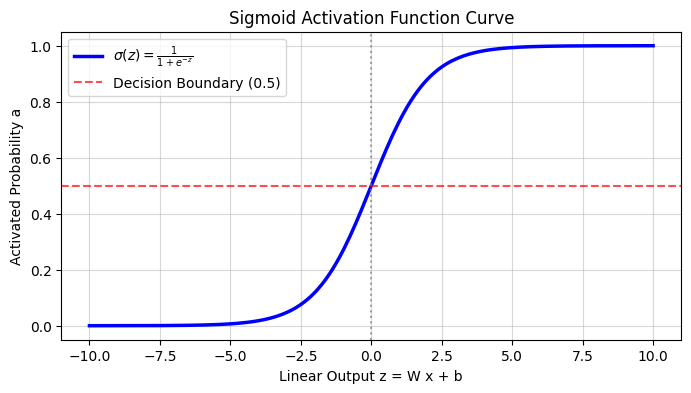

In [10]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z_vals = np.linspace(-10, 10, 200)
a_vals = sigmoid(z_vals)

plt.figure(figsize=(8, 4))
plt.plot(z_vals, a_vals, 'b-', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
plt.axhline(0.5, color='r', linestyle='--', alpha=0.7, label='Decision Boundary (0.5)')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7)
plt.grid(True, alpha=0.5)
plt.title('Sigmoid Activation Function Curve')
plt.xlabel('Linear Output z = W x + b')
plt.ylabel('Activated Probability a')
plt.legend()
plt.show()
